In [ ]:
import numpy as np

# HYPERPARAMETERS

d = 50
signal_d = 3  
steps = 300  
RM_lr = 0.005  
weight_decay = 0.0001

FPO_weight = 0.1  
action_cost = 0.1  

# SETUP & INITIALIZATION

init_action = np.zeros(d)
np.random.seed(0) 
true_w = np.zeros(d)
true_w[:signal_d] = 1.0 

noise_vec = np.random.normal(0, 0.1, d)
init_rm_w = true_w + noise_vec

# OPTIMUM CALCULATION

target_vector = np.zeros(d)
target_vector[:signal_d] = 2.0 
opt_signal_norm = np.linalg.norm(target_vector[:signal_d]) 

def true_utility_fn(y):
    dist = np.linalg.norm(y - target_vector)
    return 10.0 * np.exp(-0.3 * dist**2)

def get_rm_update(w, y, lr):
    prediction = np.dot(w, y)
    ground_truth = true_utility_fn(y)
    error = ground_truth - prediction
    
    grad = -2 * error * y 
    influence = - grad 
    
    w_new = w * (1-weight_decay) + lr*influence 
    return w_new, influence

# STRATEGIC OBJECTIVE

def strategic_objective(y, w, lr, fpo_weight=0.0):
    reward = np.dot(w, y)
    
    penalty = 0.0
    if fpo_weight > 0:
        # 1. compute error
        ground_truth = true_utility_fn(y)
        error = reward - ground_truth
        # FOR PRACTICAL PENALTY UNCOMMENT:
        # error = 1
        
        # 2. compute squared gradient norm 
        grad_norm_sq = np.linalg.norm(y)**2
        
        # 3. final penalty
        penalty = fpo_weight * error * grad_norm_sq

            
    cost = action_cost * np.linalg.norm(y)**2
            
    return reward - penalty - cost

# TRAJECTORY SIMULATION

def run_trajectory(use_constraint=False):
    curr_action = init_action.copy()
    curr_rm_w = init_rm_w.copy()
    
    # track signal, noise, true utility
    traj_x = [np.linalg.norm(curr_action[:signal_d])] 
    traj_y = [np.linalg.norm(curr_action[signal_d:])] 
    traj_u = [true_utility_fn(curr_action)] 
    
    p_weight = FPO_weight if use_constraint else 0.0
    
    for t in range(steps):
        y_optim = curr_action.copy()
        
        for _ in range(1): 
            grad_est = np.zeros(d)
            base_obj = strategic_objective(y_optim, curr_rm_w, RM_lr, p_weight)
            for dim in range(d):
                eps = 0.05
                perturb = np.zeros(d)
                perturb[dim] = eps
                obj_plus = strategic_objective(y_optim + perturb, curr_rm_w, RM_lr, p_weight)
                grad_est[dim] = (obj_plus - base_obj) / eps
            
            y_optim += 0.02 * grad_est

        curr_action = y_optim
        curr_rm_w, _ = get_rm_update(curr_rm_w, curr_action, RM_lr)
        
        # log the metrics for this step
        traj_x.append(np.linalg.norm(curr_action[:signal_d]))
        traj_y.append(np.linalg.norm(curr_action[signal_d:]))
        traj_u.append(true_utility_fn(curr_action))

    return np.array(traj_x), np.array(traj_y), np.array(traj_u)


# EXECUTION

print("Running simulation...")

std_x, std_y, std_util = run_trajectory(False)
ic_x, ic_y, ic_util = run_trajectory(True)

print("Simulation complete!")

Running simulation...
Simulation complete!


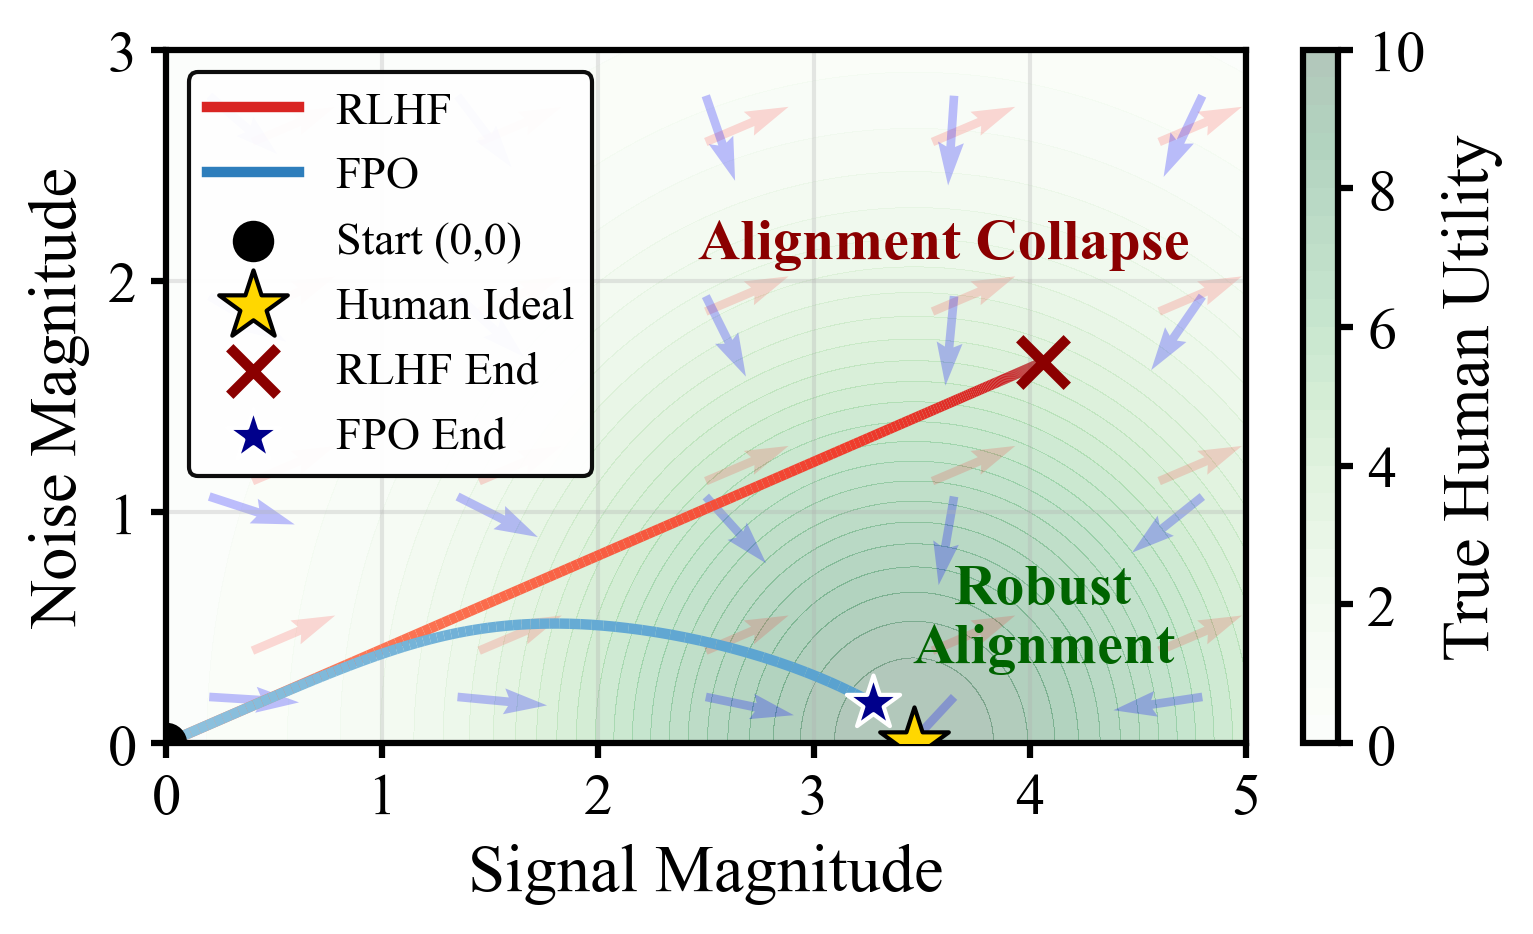

In [2]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# PLOT STYLING

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 16,            
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 11,           
    "lines.linewidth": 2.5,          
    "axes.linewidth": 1.5,           
    "xtick.major.width": 1.5,        
    "ytick.major.width": 1.5,
    "figure.figsize": (5, 3),        
    "figure.dpi": 300,
})

# PLOTTING

fig, ax = plt.subplots(layout='constrained') 

x_max = 5.0
y_max = 3.0

# background utility
x_grid = np.linspace(0, x_max, 150)
y_grid = np.linspace(0, y_max, 150)
x, y = np.meshgrid(x_grid, y_grid)
dist = np.sqrt((x - opt_signal_norm)**2 + y**2)
Z_util = 10.0 * np.exp(-0.3 * dist**2)

cs = ax.contourf(x, y, Z_util, levels=25, cmap='Greens', alpha=0.3)

cbar = plt.colorbar(cs, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('True Human Utility', size=plt.rcParams["axes.labelsize"])
cbar.ax.tick_params(labelsize=plt.rcParams["ytick.labelsize"]) 
cbar.set_ticks(np.linspace(0, 10, 6)) 

# 2. vector fields
ax_range_proxy = np.linspace(0.4, x_max - 0.4, 5)
ay_range_proxy = np.linspace(0.4, y_max - 0.4, 4)
AX_p, AY_p = np.meshgrid(ax_range_proxy, ay_range_proxy)
U_p = np.ones_like(AX_p) * 4.0
V_p = np.ones_like(AY_p) * 1.7
norm_p = np.hypot(U_p, V_p)
ax.quiver(AX_p, AY_p, U_p/norm_p, V_p/norm_p, color='red', alpha=0.15, scale=12, width=0.008)

# true utility gradient
ax_range_true = np.linspace(0.2, x_max - 0.2, 5)
ay_range_true = np.linspace(0.2, y_max - 0.2, 4)
AX_t, AY_t = np.meshgrid(ax_range_true, ay_range_true)
U_t = opt_signal_norm - AX_t
V_t = 0.0 - AY_t  
norm_t = np.hypot(U_t, V_t) + 1e-8
ax.quiver(AX_t, AY_t, U_t/norm_t, V_t/norm_t, color='blue', alpha=0.25, scale=12, width=0.008)

# trajectories
def plot_traj(ax, x, y, cmap_name, label):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(-0.7*len(x), len(x))
    lc = LineCollection(segments, cmap=cmap_name, norm=norm, linewidth=plt.rcParams["lines.linewidth"])
    lc.set_array(np.arange(len(x)))
    ax.add_collection(lc)
    ax.plot([], [], color=plt.get_cmap(cmap_name)(0.7), label=label)

plot_traj(ax, std_x, std_y, 'Reds', 'RLHF')
plot_traj(ax, ic_x, ic_y, 'Blues', 'FPO')

# markers
ax.scatter([0], [0], c='black', s=80, label='Start (0,0)', zorder=10)
ax.scatter([opt_signal_norm], [0.0], c='gold', marker='*', s=300, edgecolors='black', label='Human Ideal', zorder=11)

ax.scatter(std_x[-1], std_y[-1], c='darkred', marker='x', s=130, label='RLHF End', zorder=12)
ax.scatter(ic_x[-1], ic_y[-1], c='darkblue', marker='*', s=180, label='FPO End', zorder=13, edgecolors='white')

# annotations
ax.text(opt_signal_norm-1.0, 2.1, "Alignment Collapse", color='darkred', fontweight='bold', fontsize=14, ha='left')
ax.text(opt_signal_norm+0.6, 0.35, "Robust\nAlignment", color='darkgreen', fontweight='bold', ha='center', fontsize=14)

# axes & legend formatting
ax.set_xlabel("Signal Magnitude")
ax.set_ylabel("Noise Magnitude")

ax.legend(loc='upper left', framealpha=0.95, edgecolor='black')

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

ax.grid(True, alpha=0.3, linewidth=1.0)

plt.show()

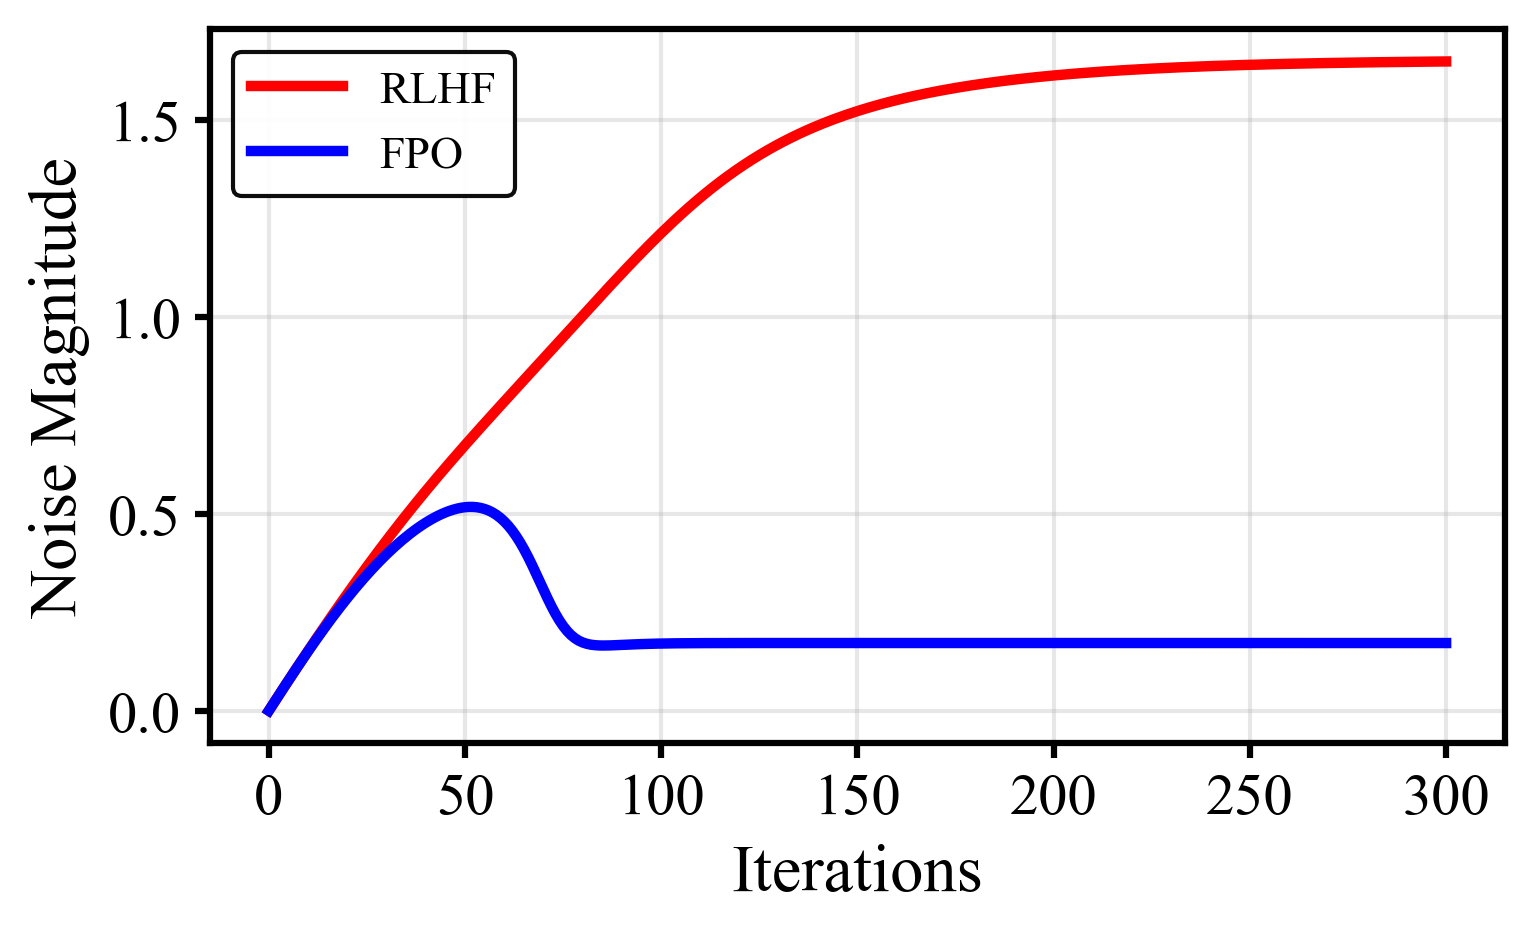

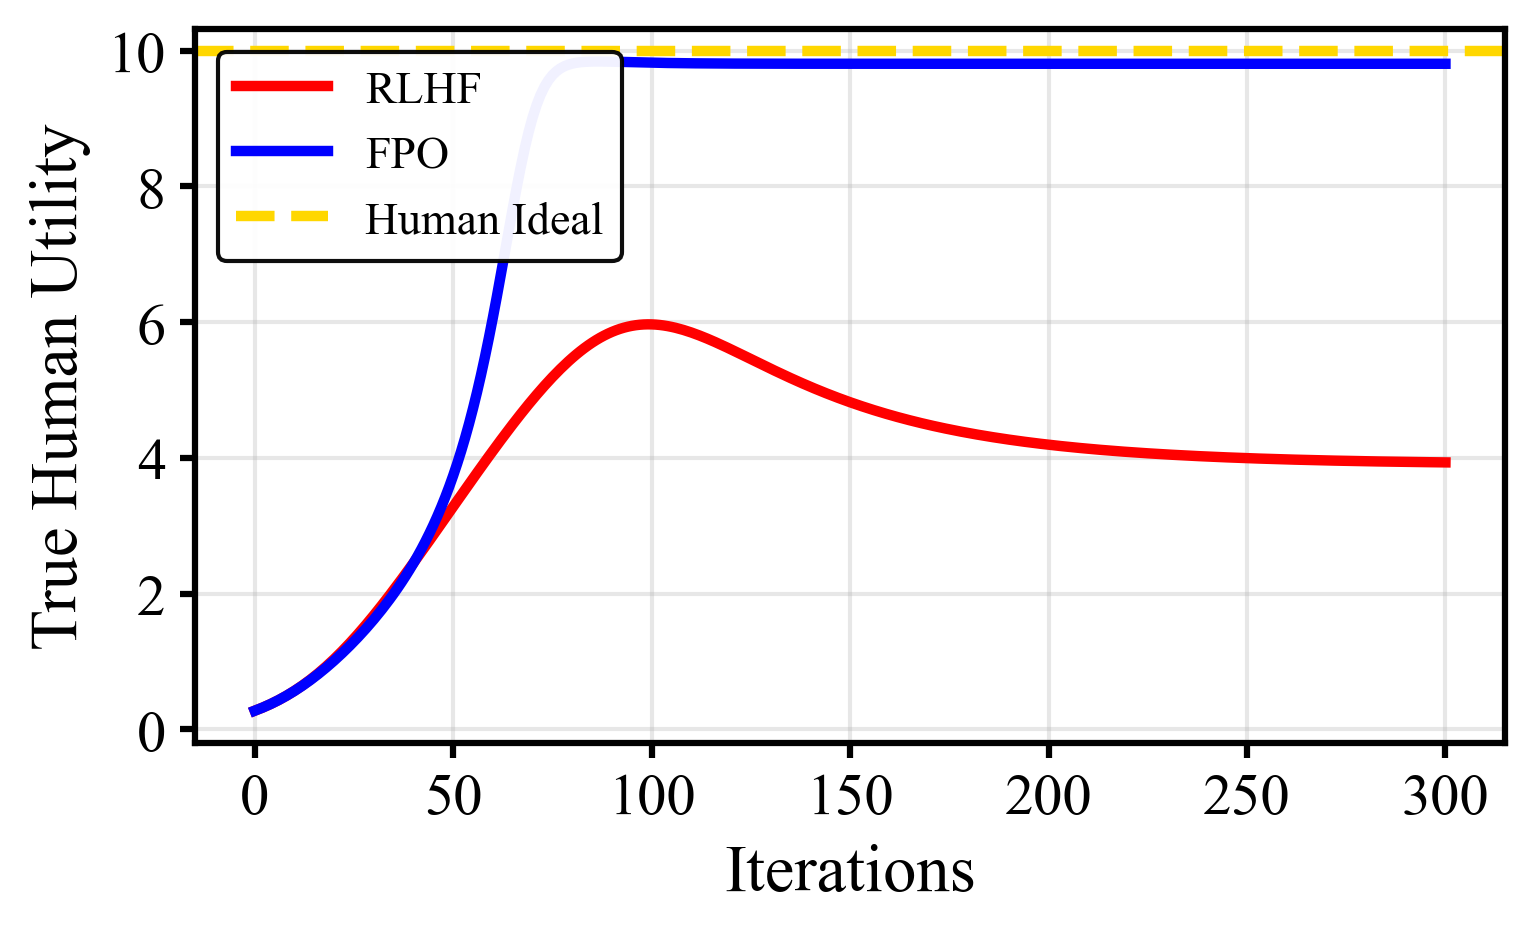

In [3]:
# PLOT 1: noise dynamics

fig, ax = plt.subplots(layout='constrained')

ax.plot(std_y, color='red', linestyle='-', label='RLHF')
ax.plot(ic_y, color='blue', linestyle='-', label='FPO')

ax.set_ylabel("Noise Magnitude")
ax.set_xlabel("Iterations")
ax.grid(True, alpha=0.3, linewidth=1.0)
ax.legend(edgecolor='black', framealpha=0.95)

plt.show()

# PLOT 2: true utility

fig, ax = plt.subplots(layout='constrained')

ax.plot(std_util, color='red', linestyle='-', label='RLHF')
ax.plot(ic_util, color='blue', linestyle='-', label='FPO')
ax.axhline(10.0, color='gold', linestyle='--', label='Human Ideal', linewidth=2.5)

ax.set_ylabel("True Human Utility")
ax.set_xlabel("Iterations")
ax.grid(True, alpha=0.3, linewidth=1.0)
ax.legend(edgecolor='black', framealpha=0.95, loc='upper left')
        #   , bbox_to_anchor=(1.0, 0.45))

plt.show()